## Tokenization Practice and Simple Document Similarity

For this notebook, you have been provided the top 50 most downloaded books from Project Gutenberg over the last 90 days as text files.

In [1]:
import re
import glob
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
from numpy import dot 
from numpy.linalg import norm 

from nltk import sent_tokenize, word_tokenize, regexp_tokenize
from nltk.corpus import stopwords

from collections import Counter

from nltk.stem import PorterStemmer, WordNetLemmatizer

Given a filepath, you can open the file and use the `read` method to extract the contents as a string.

For example, if we want to import the full text of War and Peace, we can do that using the following block of code.

In [2]:
filepath = 'books/War and Peace by graf Leo Tolstoy.txt'

with open(filepath, encoding = 'utf-8') as fi:
    book = fi.read()

You'll notice that there is some metadata at the top of the file and at the bottom of the file.

In [3]:
book[:1000]

'\ufeffThe Project Gutenberg eBook of War and Peace, by Leo Tolstoy\n\nThis eBook is for the use of anyone anywhere in the United States and\nmost other parts of the world at no cost and with almost no restrictions\nwhatsoever. You may copy it, give it away or re-use it under the terms\nof the Project Gutenberg License included with this eBook or online at\nwww.gutenberg.org. If you are not located in the United States, you\nwill have to check the laws of the country where you are located before\nusing this eBook.\n\nTitle: War and Peace\n\nAuthor: Leo Tolstoy\n\nTranslators: Louise and Aylmer Maude\n\nRelease Date: April, 2001 [eBook #2600]\n[Most recently updated: January 21, 2019]\n\nLanguage: English\n\nCharacter set encoding: UTF-8\n\nProduced by: An Anonymous Volunteer and David Widger\n\n*** START OF THE PROJECT GUTENBERG EBOOK WAR AND PEACE ***\n\n\n\n\nWAR AND PEACE\n\n\nBy Leo Tolstoy/Tolstoi\n\n\n    Contents\n\n    BOOK ONE: 1805\n\n    CHAPTER I\n\n    CHAPTER II\n\n    CH

In [4]:
book[-18420:]

'scious.\n\n\n\n\n*** END OF THE PROJECT GUTENBERG EBOOK WAR AND PEACE ***\n\nUpdated editions will replace the previous one--the old editions will\nbe renamed.\n\nCreating the works from print editions not protected by U.S. copyright\nlaw means that no one owns a United States copyright in these works,\nso the Foundation (and you!) can copy and distribute it in the\nUnited States without permission and without paying copyright\nroyalties. Special rules, set forth in the General Terms of Use part\nof this license, apply to copying and distributing Project\nGutenberg-tm electronic works to protect the PROJECT GUTENBERG-tm\nconcept and trademark. Project Gutenberg is a registered trademark,\nand may not be used if you charge for an eBook, except by following\nthe terms of the trademark license, including paying royalties for use\nof the Project Gutenberg trademark. If you do not charge anything for\ncopies of this eBook, complying with the trademark license is very\neasy. You may use thi

In [5]:
filepath = 'books/A Modest Proposal by Jonathan Swift.txt'

with open(filepath, encoding = 'utf-8') as fi:
    book = fi.read()

In [6]:
book[:1000]

'\ufeffThe Project Gutenberg eBook of A Modest Proposal, by Jonathan Swift\n\nThis eBook is for the use of anyone anywhere in the United States and\nmost other parts of the world at no cost and with almost no restrictions\nwhatsoever. You may copy it, give it away or re-use it under the terms\nof the Project Gutenberg License included with this eBook or online at\nwww.gutenberg.org. If you are not located in the United States, you\nwill have to check the laws of the country where you are located before\nusing this eBook.\n\nTitle: A Modest Proposal\n       For preventing the children of poor people in Ireland, from\n       being a burden on their parents or country, and for making\n       them beneficial to the publick\n\nAuthor: Jonathan Swift\n\nRelease Date: October, 1997 [eBook #1080]\n[Most recently updated: October 17, 2019]\n\nLanguage: English\n\nCharacter set encoding: UTF-8\n\nProduced by: An Anonymous Volunteer and David Widger\n\n*** START OF THE PROJECT GUTENBERG EBOOK A M

In [7]:
book[-20000:]

'figure throughout\nthis kingdom, whose whole subsistence put into a common stock, would\nleave them in debt two million of pounds sterling, adding those who are\nbeggars by profession, to the bulk of farmers, cottagers and labourers,\nwith their wives and children, who are beggars in effect; I desire\nthose politicians who dislike my overture, and may perhaps be so bold\nto attempt an answer, that they will first ask the parents of these\nmortals, whether they would not at this day think it a great happiness\nto have been sold for food at a year old, in the manner I prescribe,\nand thereby have avoided such a perpetual scene of misfortunes, as they\nhave since gone through, by the oppression of landlords, the\nimpossibility of paying rent without money or trade, the want of common\nsustenance, with neither house nor clothes to cover them from the\ninclemencies of the weather, and the most inevitable prospect of\nintailing the like, or greater miseries, upon their breed for ever.\n\nI 

Write some code that will remove this text at the bottom and top of the string.

**Hint:** You might want to make use of the [`re.search`](https://docs.python.org/3/library/re.html#re.search) function from the `re` library.

In [8]:
book[:1000]

'\ufeffThe Project Gutenberg eBook of A Modest Proposal, by Jonathan Swift\n\nThis eBook is for the use of anyone anywhere in the United States and\nmost other parts of the world at no cost and with almost no restrictions\nwhatsoever. You may copy it, give it away or re-use it under the terms\nof the Project Gutenberg License included with this eBook or online at\nwww.gutenberg.org. If you are not located in the United States, you\nwill have to check the laws of the country where you are located before\nusing this eBook.\n\nTitle: A Modest Proposal\n       For preventing the children of poor people in Ireland, from\n       being a burden on their parents or country, and for making\n       them beneficial to the publick\n\nAuthor: Jonathan Swift\n\nRelease Date: October, 1997 [eBook #1080]\n[Most recently updated: October 17, 2019]\n\nLanguage: English\n\nCharacter set encoding: UTF-8\n\nProduced by: An Anonymous Volunteer and David Widger\n\n*** START OF THE PROJECT GUTENBERG EBOOK A M

In [9]:
pattern = r'START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*\*\*\*\n+(.*?)\n+\*\*\* END OF (THE|THIS) PROJECT GUTENBERG EBOOK'
# We need to use re.DOTALL to enable the regex to match newline characters
s = re.search(pattern, book, re.DOTALL)

In [10]:
s.group(2)

'A Modest Proposal\n\nFor preventing the children of poor people in Ireland,\nfrom being a burden on their parents or country,\nand for making them beneficial to the publick.\n\nby Dr. Jonathan Swift\n\n1729\n\n\n\n\nIt is a melancholy object to those, who walk through this great town,\nor travel in the country, when they see the streets, the roads, and\ncabbin-doors crowded with beggars of the female sex, followed by three,\nfour, or six children, all in rags, and importuning every passenger for\nan alms. These mothers, instead of being able to work for their honest\nlivelihood, are forced to employ all their time in stroling to beg\nsustenance for their helpless infants who, as they grow up, either turn\nthieves for want of work, or leave their dear native country, to fight\nfor the Pretender in Spain, or sell themselves to the Barbadoes.\n\nI think it is agreed by all parties, that this prodigious number of\nchildren in the arms, or on the backs, or at the heels of their\nmothers, a

If we want to be able to scale up our analysis to multiple books, it would be nice to have a function to use repeatedly. Write a function called `import_book` which takes as an argument a filepath and returns the contents of that file as a string with the metadata at the top and bottom removed.

In [11]:
def import_book(filepath):
    with open(filepath, encoding = 'utf-8') as fi:
        book = fi.read()
    pattern = r'START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*\*\*\*\n+(.*?)\n+\*\*\* END OF (THE|THIS) PROJECT GUTENBERG EBOOK'
    # We need to use re.DOTALL to enable the regex to match newline characters
    s = re.search(pattern, book, re.DOTALL)
    return s.group(2)

Now, let's utilize our function to import all of the books into a data structure of some kind.

First, we need to be able to iterate through the list of filepaths. For this, we can use the `glob` function. This function takes as agument a pattern to match. Try it out.

In [12]:
glob.glob('books/*.txt')

['books/Pygmalion by Bernard Shaw.txt',
 'books/The War of the Worlds by H. G.  Wells.txt',
 'books/Leviathan by Thomas Hobbes.txt',
 'books/Don Quixote by Miguel de Cervantes Saavedra.txt',
 'books/The Awakening, and Selected Short Stories by Kate Chopin.txt',
 'books/The Count of Monte Cristo, Illustrated by Alexandre Dumas.txt',
 'books/Les Misérables by Victor Hugo.txt',
 'books/The Republic by Plato.txt',
 'books/Walden, and On The Duty Of Civil Disobedience by Henry David Thoreau.txt',
 'books/Dubliners by James Joyce.txt',
 'books/Great Expectations by Charles Dickens.txt',
 'books/Anthem by Ayn Rand.txt',
 'books/Anna Karenina by graf Leo Tolstoy.txt',
 'books/The Yellow Wallpaper by Charlotte Perkins Gilman.txt',
 'books/Moby Dick; Or, The Whale by Herman Melville.txt',
 'books/The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt',
 'books/The Scarlet Letter by Nathaniel Hawthorne.txt',
 'books/The Prince by Niccolò Machiavelli.txt',
 'books/Japanese Girls and Women b

In [13]:
filepath = glob.glob('books/*.txt')[0]
filepath

'books/Pygmalion by Bernard Shaw.txt'

It would be nice to save the title of each book without the extra pieces around it. Write code that will remove the "books/" from the front of the filepath and the ".txt" from the end. That is, we want to extract just the "Little Women by Louisa May Alcott" from the current filepath.

In [14]:
pattern = r'books/(.*?)\.txt'
title = re.search(pattern, filepath).group(1)
title

'Pygmalion by Bernard Shaw'

Now, combine together the function you created and the code that you just wrote to iterate through the filepaths for the books and save the contents of each book into a dictionary whose keys are equal to the cleaned up titles.

In [15]:
books = {}
for filepath in glob.glob('books/*.txt'):
    title = re.search(r'books/(.*?)\.txt', filepath).group(1)
    contents = import_book(filepath)
    books[title] = contents

In [16]:
books['Pygmalion by Bernard Shaw'][:1000]

'The rest of the story need not be shown in action, and indeed, would\nhardly need telling if our imaginations were not so enfeebled by their\nlazy dependence on the ready-makes and reach-me-downs of the ragshop in\nwhich Romance keeps its stock of “happy endings” to misfit all stories.\nNow, the history of Eliza Doolittle, though called a romance because of\nthe transfiguration it records seems exceedingly improbable, is common\nenough. Such transfigurations have been achieved by hundreds of\nresolutely ambitious young women since Nell Gwynne set them the example\nby playing queens and fascinating kings in the theatre in which she\nbegan by selling oranges. Nevertheless, people in all directions have\nassumed, for no other reason than that she became the heroine of a\nromance, that she must have married the hero of it. This is unbearable,\nnot only because her little drama, if acted on such a thoughtless\nassumption, must be spoiled, but because the true sequel is patent to\nanyone wi

Now let's write some code so that we can cluster our books. In order to cluster, we'll need to be able to compute a similarity or distance between books.

A simple way to compute similarity of documents is the [Jaccard similarity](https://en.wikipedia.org/wiki/Jaccard_index) of the set of words that they conain. This metric computes the amount of overlap between two sets compared to their union. Two books which contain exactly the same words (but not necessarily in the same order or with the same frequency) will have a Jaccard similarity of 1 and two books which have no words in common will have a Jaccard similarity of 0.

**Question:** What might be some of the downsides to using Jaccard similarity to compute the similarity of two books?
The Jaccard similarity might not capture the tone or intent of the book. For example, 2 books arguing completely different sides of an issue might have a very high Jaccard similarity, but very different conclusions. 

In order to use this, we'll need to tokenize each book and store the results in a collection of some kind. Since we are interested in which words appear but not necessarily in what order or how frequently, we can make use of a [set](https://docs.python.org/3/library/stdtypes.html#set-types-set-frozenset). A set is similar to a list, but the order of the contents does not matter and a set cannot contain duplicates.

For practice, let's grab one of our books.

In [17]:
book = books['Little Women by Louisa May Alcott']

Write some code which tokenizes Little Women and stores the tokens it contains in a set. It is up to you to decide exactly how you want to tokenize or what you want to count as a token.

Once you are happy with your tokenization method, convert it into a function named `tokenize_book` which takes in a string and returns a set of tokens.

In [18]:
def tokenize_book(contents):
    stop_words = set(stopwords.words('english'))
    wnl = WordNetLemmatizer()
    # Explanation of regex: matches the start of the word, then begins a non-capturing group with either a single hyphen or apostrophe followed by the rest of the word (one or more times)
    # Prevents double hyphens from being captured as part of a token 
    return set([wnl.lemmatize(x.lower()) for x in regexp_tokenize(contents, r'\w+(?:[\'-]\w+)*') if x.lower() not in stop_words])

Now, write a function `jaccard` which takes in two sets of tokens and returns the Jaccard similarities between them. **Hint:** Python sets have `intersection` and `union` methods.

In [19]:
def jaccard(set1, set2):
    return len(set1.intersection(set2)) / len(set1.union(set2))

Is Little Women more similar (using Jaccard Similarity) to Heart of Darkness or Anthem?

In [20]:
jaccard(tokenize_book(books['Little Women by Louisa May Alcott']), tokenize_book(books['Heart of Darkness by Joseph Conrad']))

0.2626775721050366

In [21]:
jaccard(tokenize_book(books['Little Women by Louisa May Alcott']), tokenize_book(books['Anthem by Ayn Rand']))

0.13388578274760382

Little Women is more similar to Heart of Darkness than to Anthem.

Let's create another dictionary called `book_tokens` that contains the title of each book as a key and the tokenized version of the book as values.

In [22]:
book_tokens = {}
for title, contents in books.items():
    book_tokens[title] = tokenize_book(contents)

Using this, let's create a distance matrix for our books using the jaccard function above. **Note:** You created a function for jaccard _similarity_. This can be converted to a **distance** by subtracting the similarity score from 1.

In [23]:
dists = np.zeros(shape = (len(book_tokens), len(book_tokens)))

Now, fill in the distance matrix so that in the i,j spot you have one minus the jaccard similarity of the ith and jth books.

In [24]:
for i in range(dists.shape[0]):
    for j in range(dists.shape[1]):
        dists[i,j] = 1 - jaccard(list(book_tokens.values())[i], list(book_tokens.values())[j])

In [25]:
dists

array([[0.        , 0.8858631 , 0.91577022, ..., 0.85645742, 0.87140047,
        0.8659306 ],
       [0.8858631 , 0.        , 0.82512412, ..., 0.73376545, 0.70008169,
        0.71372003],
       [0.91577022, 0.82512412, 0.        , ..., 0.8396468 , 0.82691158,
        0.79486968],
       ...,
       [0.85645742, 0.73376545, 0.8396468 , ..., 0.        , 0.71192963,
        0.7030993 ],
       [0.87140047, 0.70008169, 0.82691158, ..., 0.71192963, 0.        ,
        0.70077891],
       [0.8659306 , 0.71372003, 0.79486968, ..., 0.7030993 , 0.70077891,
        0.        ]])

Once we have our distance matrix, we can compute a **dendogram**. 

A dendogram is a way to visualize a hierarchical clustering of a dataset. You can read more about it [here](https://www.statisticshowto.com/hierarchical-clustering/).

In [26]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

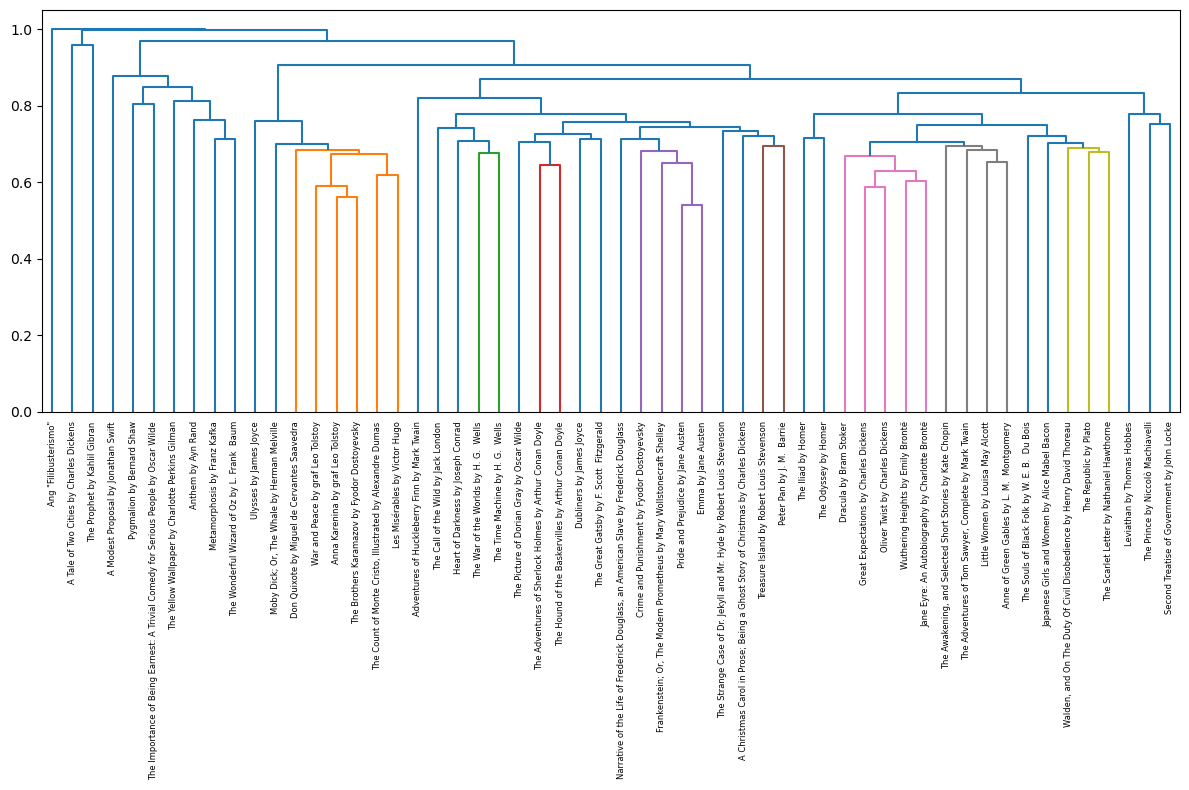

In [27]:
mergings = linkage(squareform(dists), method='complete')

plt.figure(figsize = (12,8))
dendrogram(mergings,
           labels = list(book_tokens.keys()),
           leaf_rotation = 90,
           leaf_font_size = 6);

plt.tight_layout()
plt.savefig('images/dendogram_complete_jaccard.png', transparent=False, facecolor='white', dpi = 150);

**Bonus Material** Jaccard Similarity does not account for the frequency that each word is used, only whether or not it is used.

We might be better off using the **cosine similarity** as a way to measure the similarity of two books.

Create a dataframe named `books_df` where each row corresponds to a book and each column corresponds to a word. It should count the number of times the word appears in that book (including zero). Use the book title as the index of this dataframe.

In [29]:
counters = []
for book in books.values():
    stop_words = set(stopwords.words('english'))
    wnl = WordNetLemmatizer()
    counters.append(Counter([wnl.lemmatize(x.lower()) for x in regexp_tokenize(book, r'\w+(?:[\'-]\w+)*') if x.lower() not in stop_words]))

# Combine Counters into one DataFrame
books_df = pd.DataFrame(counters).fillna(0)
# Index with book titiles
books_df.index = books.keys()

In [30]:
books_df.head()

,rest,story,need,shown,action,indeed,would,hardly,telling,imagination,...,pavlitch,bah-bah-bah,hulloa,pledge_,voznesensky,hypochondriacal,zossimov,razumihins,guard-room,irtish
Pygmalion by Bernard Shaw,1.0,2.0,5.0,1.0,1.0,2.0,24.0,2.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
The War of the Worlds by H. G. Wells,13.0,18.0,8.0,1.0,19.0,22.0,102.0,1.0,3.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Leviathan by Thomas Hobbes,66.0,4.0,95.0,2.0,251.0,23.0,137.0,8.0,1.0,56.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Don Quixote by Miguel de Cervantes Saavedra,128.0,189.0,124.0,47.0,15.0,125.0,1250.0,43.0,70.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"The Awakening, and Selected Short Stories by Kate Chopin",22.0,17.0,16.0,0.0,10.0,7.0,198.0,5.0,15.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
def cosine_similarity(v1, v2): 
    return dot(v1, v2) / (norm(v1) * norm(v2))

In [32]:
# Creating a new distance matrix to be used with cosine similarity
cos_dists = np.zeros(shape = (len(books), len(books)))

In [33]:
for i in range(dists.shape[0]):
    for j in range(dists.shape[1]):
        cos_dists[i,j] = cosine_similarity(books_df.iloc[i], books_df.iloc[j])

In [34]:
cos_dists

array([[1.        , 0.36465868, 0.26357908, ..., 0.35747042, 0.45603555,
        0.43929403],
       [0.36465868, 1.        , 0.38732027, ..., 0.50155312, 0.71085083,
        0.58869044],
       [0.26357908, 0.38732027, 1.        , ..., 0.29648003, 0.441969  ,
        0.40086716],
       ...,
       [0.35747042, 0.50155312, 0.29648003, ..., 1.        , 0.6110302 ,
        0.57755926],
       [0.45603555, 0.71085083, 0.441969  , ..., 0.6110302 , 1.        ,
        0.72937815],
       [0.43929403, 0.58869044, 0.40086716, ..., 0.57755926, 0.72937815,
        1.        ]])